# Exploratory Data Analysis

In [1]:
# Import all libraries needed for that EDA

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
import numpy as np

In [2]:
# Separate data preparation from data utilization

csv_path = Path("../data/processed/df_full.csv")
parquet_path = Path("../data/processed/df_full.parquet")

if not parquet_path.exists():
    print("CSV conversion → Parquet")
    df = pd.read_csv(csv_path)
    df.to_parquet(parquet_path, engine="fastparquet")
else:
    print("Parquet already present, conversion ignored")

Parquet already present, conversion ignored


In [3]:
df = pd.read_parquet("../data/processed/df_full.parquet", engine="fastparquet")

In [4]:
df.head(10)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry
5,2,17794,6,1,202279,prior,3,5,9,8.0,Carrots,83,4,fresh vegetables,produce
6,2,40141,7,1,202279,prior,3,5,9,8.0,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry
7,2,1819,8,1,202279,prior,3,5,9,8.0,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry
8,2,43668,9,0,202279,prior,3,5,9,8.0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce
9,3,33754,1,1,205970,prior,16,5,17,12.0,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs


In [5]:
df.shape

(33819106, 15)

| Columns          |        Description         |
|------------------|:--------------------------:|
| **order_id**     | Each order has a unique ID |
| **user_id**      | Each user has a unique ID  |
| **eval_set**     |         This variable specifies the type of the dataset. It can take three different values: “prior,” “train,” and “test.”         |
| **order_number** | Indicates the order within each user's order. |
| **order_dow**      | Indicates which day of the week the order was placed (a number from 0 to 6, Sunday to Saturday).  |
| **order_hour_of_day**     |         Indicates the time of day the order was placed (a number from 0 to 23).         |
| **days_since_prior_order**     |        Indicates the number of days that have passed since the previous order. If this is a user's first order, it may be NaN (Not a Number).         |

**prior** : This value represents the pre-training (prior) portion of the dataset. That is, users' past orders belong to this category.

**train** : This value represents the training dataset. It is the section where the model is trained and the learning process takes place. The model learns using the data in this section.

**test** : This value represents the test dataset. It is the section where the model's performance is evaluated and predictions are made after training. The data in this section typically contains new data that the model has not seen before and must predict.

In [6]:
df.isna().sum()

order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64

In [7]:
df.aisle.value_counts()

aisle
fresh fruits                  3792661
fresh vegetables              3568630
packaged vegetables fruits    1843806
yogurt                        1507583
packaged cheese               1021462
                               ...   
eye ear care                     9522
baby bath body care              8909
baby accessories                 8466
beauty                           6455
frozen juice                     5147
Name: count, Length: 134, dtype: int64

## Customers' temporal purchasing habits

In [8]:
df.order_hour_of_day.value_counts().sort_index()

order_hour_of_day
0      228031
1      121412
2       72660
3       53759
4       55714
5       91909
6      302642
7      928239
8     1787359
9     2550569
10    2874905
11    2852701
12    2732599
13    2778054
14    2810918
15    2780731
16    2647695
17    2186409
18    1714445
19    1317576
20    1017958
21     831183
22     662053
23     419585
Name: count, dtype: int64

In [9]:
df["department"] = df["department"].astype("category")
df["reordered"] = df["reordered"].astype("category")

In [10]:
df["order_dow"].value_counts().sort_index()

order_dow
0    6533692
1    5871834
2    4378360
3    3998498
4    3942696
5    4386443
6    4707583
Name: count, dtype: int64

#### When do customers order the most?

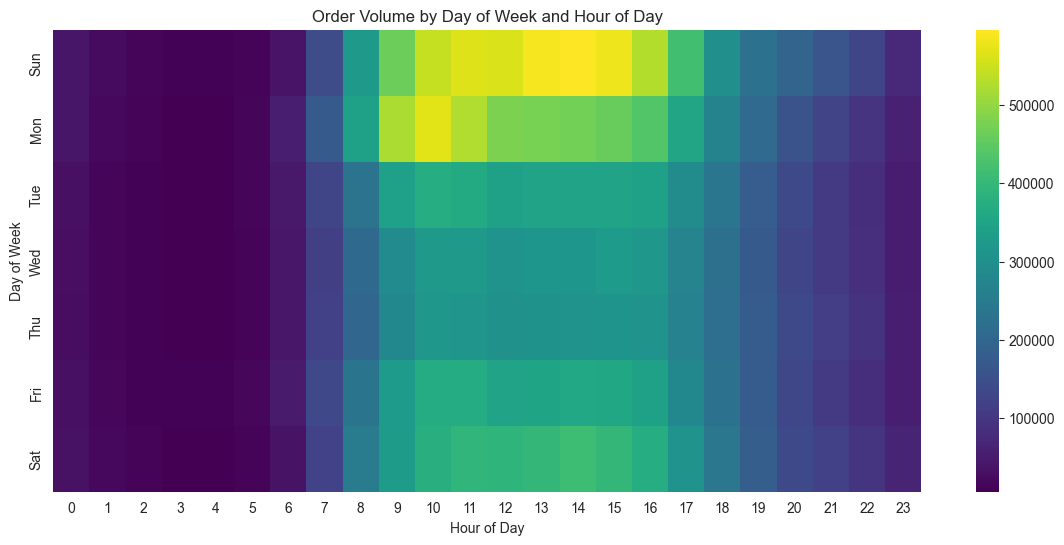

In [11]:
# Through this graph, we want to know at what time and on what day of the week the most orders are placed. This therefore reflects customer activity in the store.

heatmap_data = (
    df.groupby(["order_dow", "order_hour_of_day"])
      .size()
      .reset_index(name="count")
)
heatmap_pivot = heatmap_data.pivot(
    index="order_dow",
    columns="order_hour_of_day",
    values="count"
)

day_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
heatmap_pivot.index = day_labels

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_pivot,
    cmap="viridis"
)

plt.title("Order Volume by Day of Week and Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

## Customers' Loyalty

### AXIS 1 — Loyalty by department
#### Which departments foster the most loyalty?

C:\Users\natha\AppData\Local\Temp\ipykernel_30160\518210209.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("department")
C:\Users\natha\AppData\Local\Temp\ipykernel_30160\518210209.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


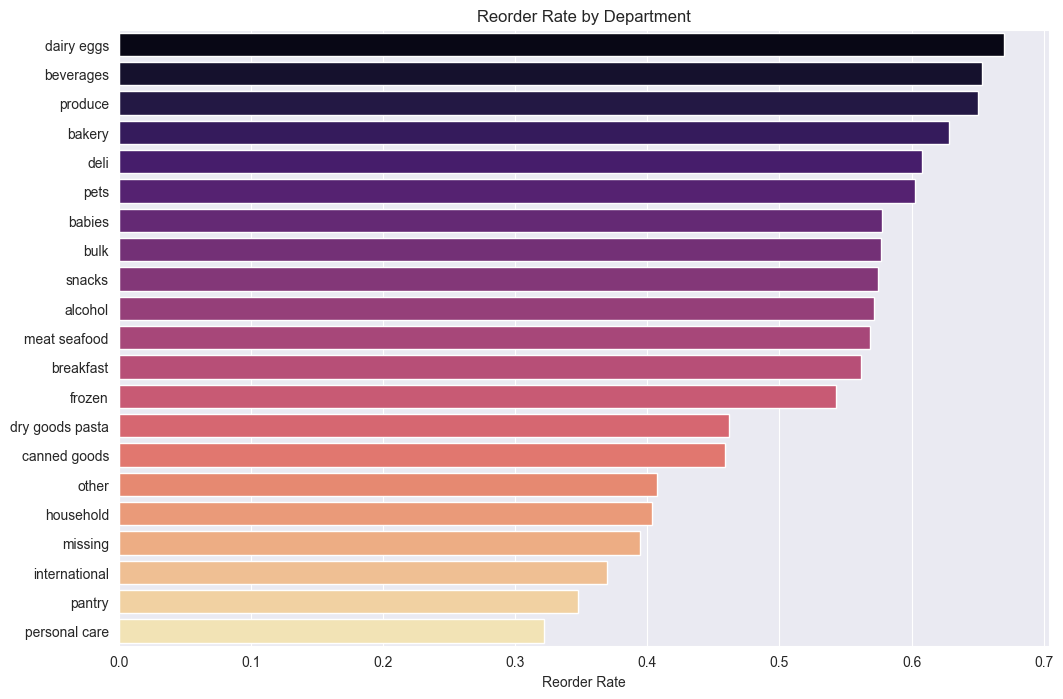

In [12]:
# With this bar chart, we want to know which departments have the highest reorder rate.
# Please note that not all departments have the same number of products, so we need to normalize the data to obtain a usable result.

df['reordered'] = df['reordered'].astype(int)

dept_loyalty = (
    df.groupby("department")
      .agg(
          total_items=("reordered", "size"),
          reordered_items=("reordered", "sum")
      )
      .assign(reorder_rate=lambda x: x["reordered_items"] / x["total_items"])
      .reset_index()
      .sort_values("reorder_rate", ascending=False)
)
plt.figure(figsize=(12,8))
sns.barplot(
    data=dept_loyalty,
    y="department",
    x="reorder_rate",
    order=dept_loyalty["department"],
    palette="magma"
)

plt.title("Reorder Rate by Department")
plt.xlabel("Reorder Rate")
plt.ylabel("")
plt.show()

### AXIS 2 — Products that promote loyalty
#### Which products account for a disproportionate share of loyalty?

threshold value : 18.0


C:\Users\natha\AppData\Local\Temp\ipykernel_30160\498450165.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


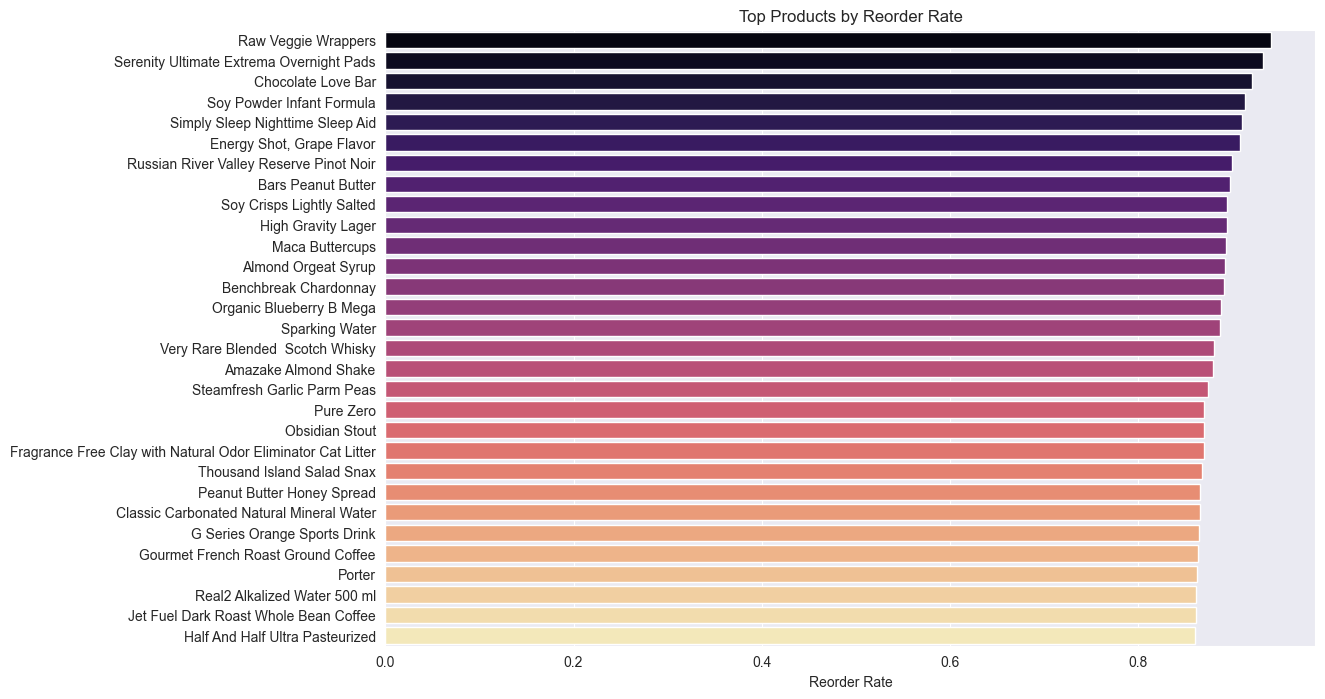

In [13]:
# In the same vein as before, we want to know which products have the highest reorder rates while normalizing by number of products to obtain usable results.

product_counts = df.groupby("product_name")["reordered"].size()
threshold = product_counts.quantile(0.25)
print("threshold value :", threshold)

product_loyalty = (
    df.groupby("product_name")
      .agg(
          total=("reordered", "size"),
          reordered=("reordered", "sum")
      )
      .query("total >= @threshold")
      .assign(reorder_rate=lambda x: x["reordered"] / x["total"])
      .sort_values("reorder_rate", ascending=False)
      .head(30)
      .reset_index()
)
plt.figure(figsize=(12,8))
sns.barplot(
    data=product_loyalty,
    y="product_name",
    x="reorder_rate",
    palette="magma"
)
plt.title("Top Products by Reorder Rate")
plt.xlabel("Reorder Rate")
plt.ylabel("")
plt.show()

In [14]:
import plotly.express as px

fig = px.scatter(
    product_loyalty,
    x="total",
    y="reorder_rate",
    size="total",                   # Bubble size reflects product popularity
    color="reorder_rate",
    hover_name="product_name",
    color_continuous_scale="magma",
    size_max=50,
)

# log scale on x-axis to handle long-tail distribution of products
# y-axis restricted to high reorder rates to highlight loyal products
fig.update_layout(
    title="Products: Reorder Rate vs Total Orders",
    xaxis_title="Total Orders",
    yaxis_title="Reorder Rate",
    yaxis=dict(range=[0.6, 1]),
    xaxis_type="log"
)

fig.show()

### AXIS 3 — Loyalty × Time
#### When is loyalty most evident ?

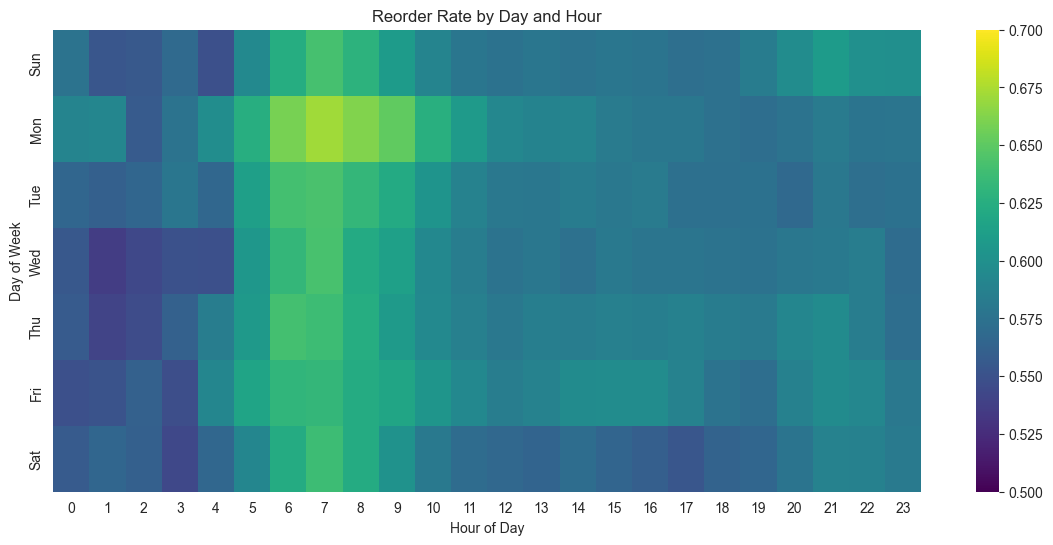

In [15]:
# Analyze reorder behavior across time dimensions
# (day of week × hour of day)

temporal_loyalty = (
    df.groupby(["order_dow", "order_hour_of_day"])
      .agg(
          total=("reordered", "size"),
          reordered=("reordered", "sum")
      )
      .assign(reorder_rate=lambda x: x["reordered"] / x["total"])
      .reset_index()
)

pivot_loyalty = temporal_loyalty.pivot(
    index="order_dow",
    columns="order_hour_of_day",
    values="reorder_rate"
)

day_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
pivot_loyalty.index = day_labels
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    pivot_loyalty,cmap="viridis", vmin=0.5, vmax=0.7
)

plt.title("Reorder Rate by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()
# These products are not just popular in the morning, they are part of stable morning routines.

#### Which products are repurchased at specific times?

C:\Users\natha\AppData\Local\Temp\ipykernel_30160\147422942.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




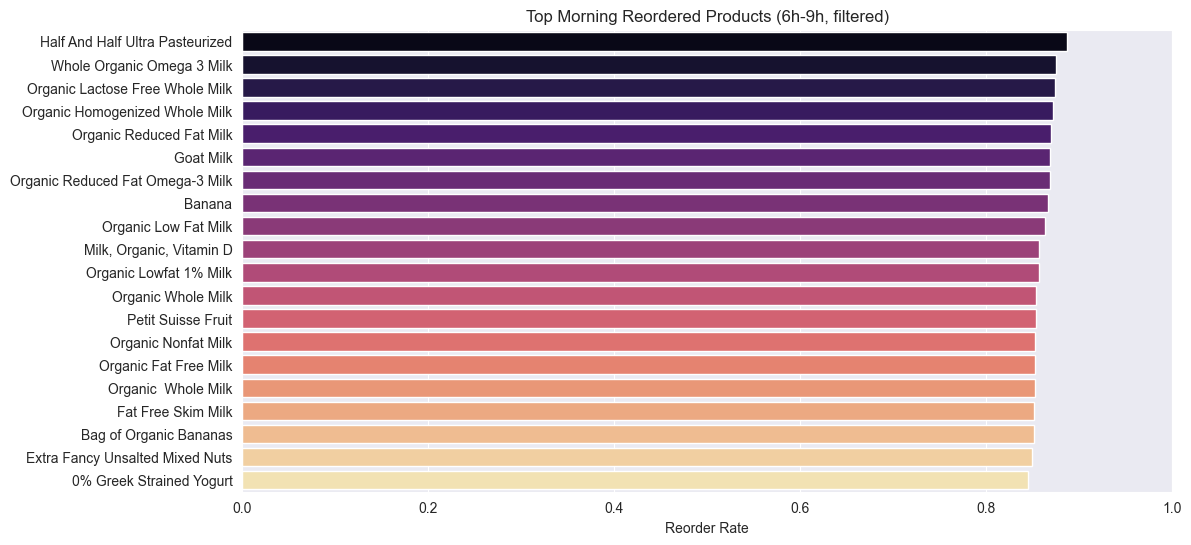

In [16]:
# Focus on morning orders to capture time-specific reorder behavior
# Morning window defined as 6 AM to 9 AM

morning = df[(df["order_hour_of_day"] >= 6) & (df["order_hour_of_day"] <= 9)]

# Aggregate product-level metrics within the morning time window
# to identify products with strong habitual reordering patterns
morning_loyalty = (
    morning.groupby("product_name")
    .agg(
        total_orders=("reordered", "size"),
        morning_reorders=("reordered", "sum"),
        n_users=("user_id", "nunique")
    )
    # Apply volume and user thresholds to ensure statistical reliability
    .query("total_orders >= 500 and n_users >= 10")
    .assign(reorder_rate=lambda x: x["morning_reorders"] / x["total_orders"])
    .sort_values("reorder_rate", ascending=False)
    .head(20)
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=morning_loyalty,
    y="product_name",
    x="reorder_rate",
    palette="magma"
)
plt.title("Top Morning Reordered Products (6h-9h, filtered)")
plt.xlabel("Reorder Rate")
plt.ylabel("")
plt.xlim(0,1)
plt.show()

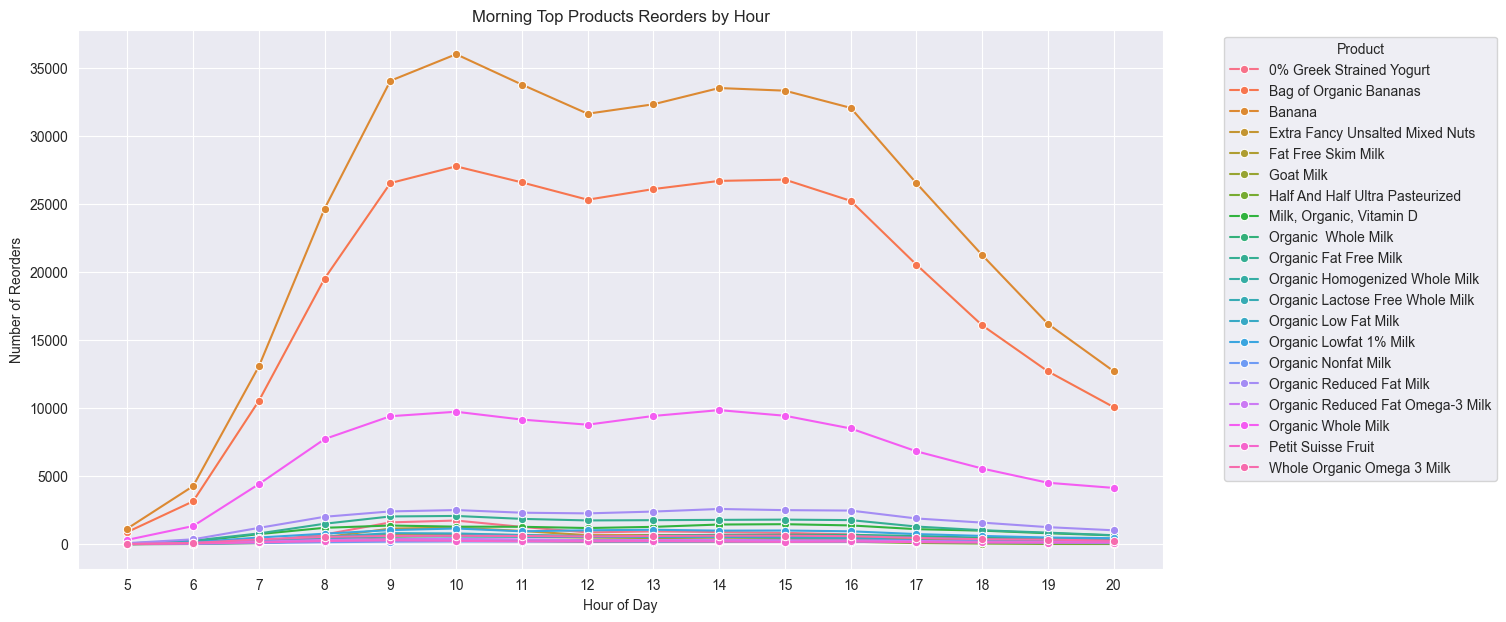

In [17]:
# Extract the list of top morning products identified previously
top_products = morning_loyalty["product_name"].tolist()

# Extend the time window to observe how these morning-driven products
# behave across the broader day (from early morning to evening)
morning_extended = df[
    (df["order_hour_of_day"] >= 5) & (df["order_hour_of_day"] <= 20) &
    (df["product_name"].isin(top_products)) &
    (df["reordered"] == 1)
]

temporal_loyalty = (
    morning_extended.groupby(["product_name", "order_hour_of_day"])
    .size()
    .reset_index(name="reorders_count")
)

plt.figure(figsize=(14,7))
sns.lineplot(
    data=temporal_loyalty,
    x="order_hour_of_day",
    y="reorders_count",
    hue="product_name",
    marker="o"
)
plt.title("Morning Top Products Reorders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Reorders")
plt.xticks(range(5,21))
plt.legend(title="Product", bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

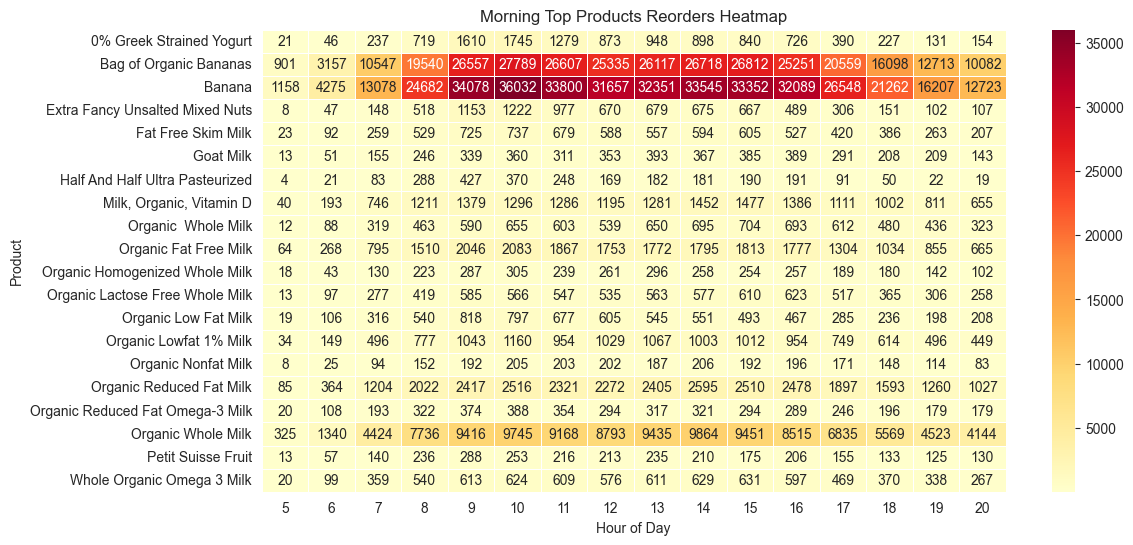

In [18]:
# Reshape hourly reorder counts into a matrix

pivot = temporal_loyalty.pivot(
    index="product_name",
    columns="order_hour_of_day",
    values="reorders_count"
)

plt.figure(figsize=(12,6))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.5,
    annot=True,
    fmt="d"
)
plt.title("Morning Top Products Reorders Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Product")
plt.show()

In [19]:
df.reordered.value_counts(normalize=True)

reordered
1    0.590062
0    0.409938
Name: proportion, dtype: float64

### We are now looking on the frequency of the customers

A customer is considered frequent based on: Total numbers of orders, Average purchase time frequency and regularity over time

In [20]:
# Frequency is not a single number, but a profile
# Several complementary metrics can be defined
client_freq = (
    df.groupby("user_id")
      .agg(
          n_orders=("order_id", "nunique"),
          avg_days_between_orders=("days_since_prior_order", "mean"),
          total_items=("product_id", "count"),
          avg_basket_size=("product_id", lambda x: x.count() / x.nunique())
      )
      .reset_index()
)

#### Are there natural types of customers based on their frequency ?

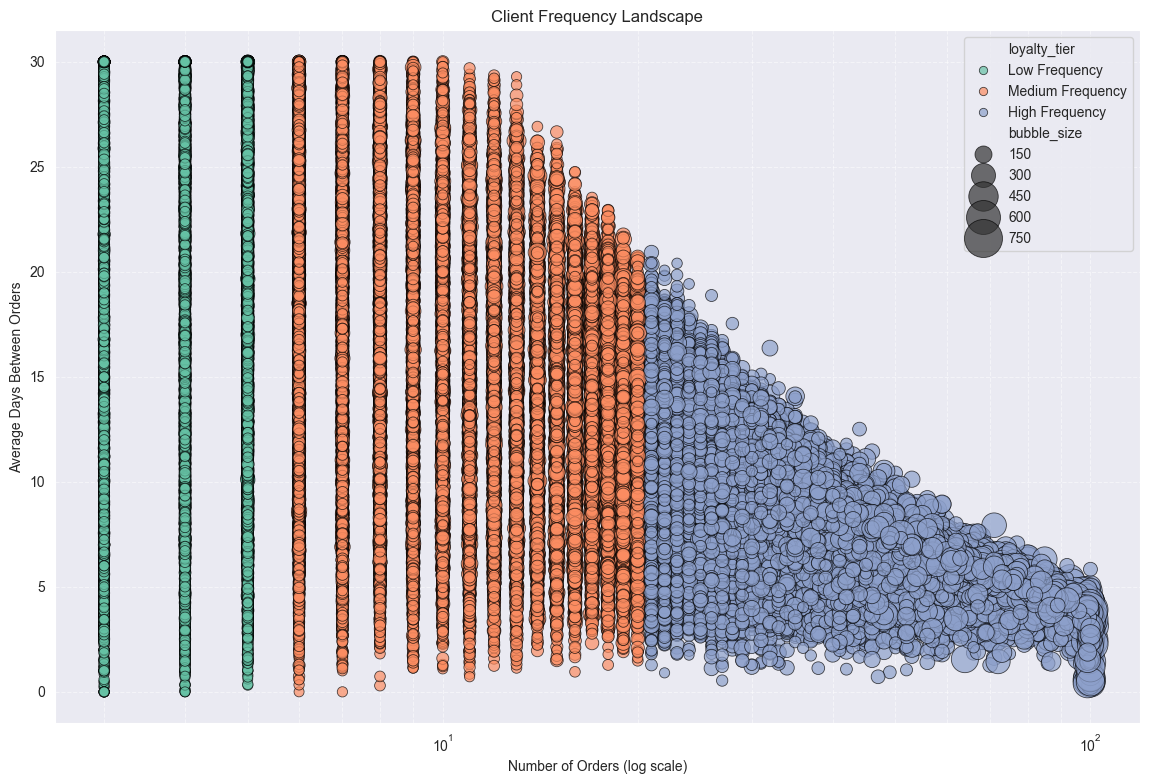

In [23]:
user_basket = (
    df.groupby("user_id")
      .agg(avg_basket_size=("order_id", "count"))
      .reset_index()
)

client_freq = (
    df.groupby("user_id")
      .agg(
          n_orders=("order_id", "nunique"),
          avg_days_between_orders=("days_since_prior_order", "mean"),
          avg_basket_size=("order_id", "count")
      )
      .reset_index()
)

client_freq['loyalty_tier'] = pd.cut(
    client_freq['n_orders'],
    bins=[0, 5, 20, np.inf],
    labels=['Low Frequency', 'Medium Frequency', 'High Frequency']
)

min_bubble = 50
max_bubble = 800
client_freq['bubble_size'] = np.interp(
    client_freq['avg_basket_size'],
    (client_freq['avg_basket_size'].min(), client_freq['avg_basket_size'].max()),
    (min_bubble, max_bubble)
)

# --- Compute median thresholds for quadrants ---
median_orders = client_freq['n_orders'].median()
median_days = client_freq['avg_days_between_orders'].median()

plt.figure(figsize=(14,9))
sns.scatterplot(
    data=client_freq,
    x='n_orders',
    y='avg_days_between_orders',
    size='bubble_size',
    hue='loyalty_tier',
    alpha=0.7,
    palette='Set2',
    sizes=(min_bubble, max_bubble),
    edgecolor='k'
)
plt.xscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlabel("Number of Orders (log scale)")
plt.ylabel("Average Days Between Orders")
plt.title("Client Frequency Landscape")
plt.show()

#### How many customers become loyal? How many drop out?

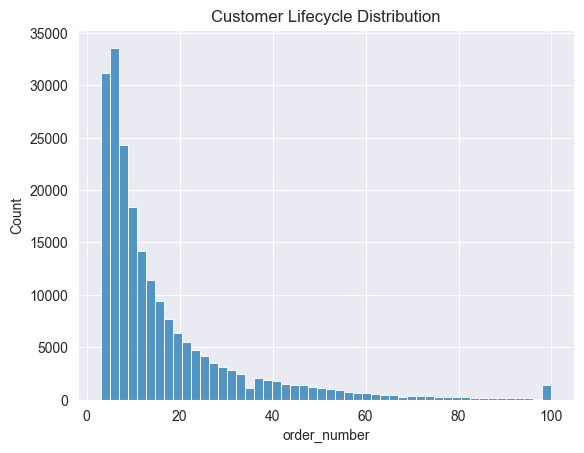

In [22]:
df_last_order = df.groupby("user_id")["order_number"].max().reset_index()

sns.histplot(df_last_order["order_number"], bins=50)
plt.title("Customer Lifecycle Distribution")
plt.show()

#### Do frequent customers buy more or less each time they visit?

C:\Users\natha\AppData\Local\Temp\ipykernel_39100\2965274303.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




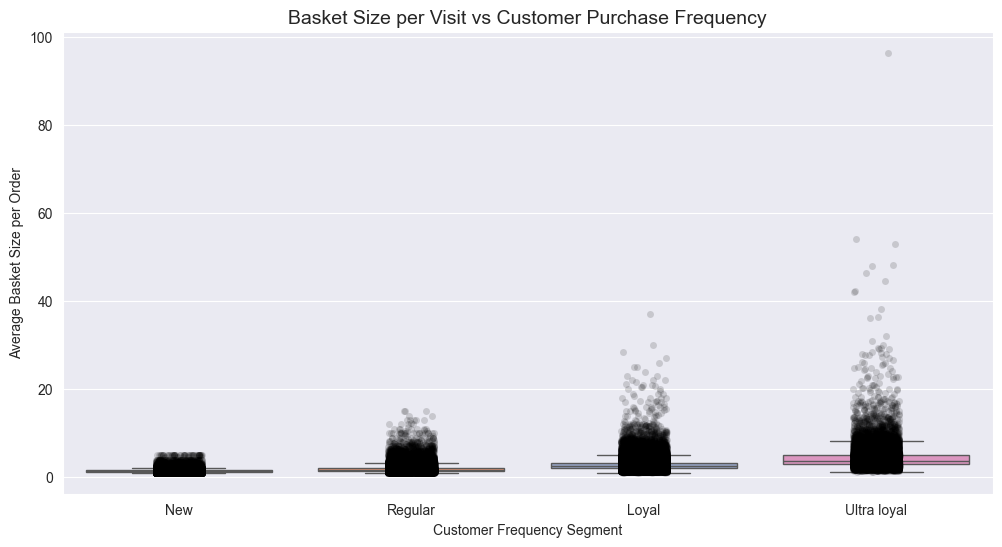

In [25]:
# Define frequency-based customer segments using order count bins
# to capture increasing levels of purchase commitment

bins = [0, 5, 15, 40, client_freq["n_orders"].max()]
labels = ["New", "Regular", "Loyal", "Ultra loyal"]

client_freq["freq_segment"] = pd.cut(
    client_freq["n_orders"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(12, 6))

# Boxplot summarizes the central tendency and dispersion
# of average basket size per order
sns.boxplot(
    data=client_freq,
    x="freq_segment",
    y="avg_basket_size",
    showfliers=False,
    palette="Set2"
)

# Stripplot overlays individual observations
# to reveal density and variability within each segment
sns.stripplot(
    data=client_freq,
    x="freq_segment",
    y="avg_basket_size",
    color="black",
    alpha=0.15,
    jitter=True
)

plt.title("Basket Size per Visit vs Customer Purchase Frequency", fontsize=14)
plt.xlabel("Customer Frequency Segment")
plt.ylabel("Average Basket Size per Order")

plt.show()

### We are now looking on the driver effect of a product
In this next section, we will see whether one or more supermarket products structure specific purchasing behavior. A “driver product” is a product that is purchased frequently by many customers. It is also a product that is associated with other products. It is a product that structures the shopping basket (size, composition).

Note that it is not necessarily the one with the highest reorder rate.
#### Universality vs loyalty

In [41]:
df["reordered"] = df["reordered"].astype(int)

# Compute product-level statistics combining reach and loyalty dimensions
product_stats = (
    df.groupby(["product_name", "department"])
      .agg(
          n_customers=("user_id", "nunique"),
          total_orders=("order_id", "size"),
          reorders=("reordered", "sum")
      )
      .assign(
          reorder_rate=lambda x: x["reorders"] / x["total_orders"]
      )
      .reset_index()
)

# Filter out low-support products to improve signal reliability
product_stats = product_stats.query(
    "total_orders >= 200 and n_customers >= 20"
)

plt.figure(figsize=(14,8))

fig = px.scatter(
    product_stats,
    x="n_customers",
    y="reorder_rate",
    size="total_orders",        # bubble size reflects sales volume
    color="department",         # color encodes product category
    hover_name="product_name",
    hover_data={
        "n_customers": True,
        "reorder_rate": ':.2f',
        "total_orders": True,
        "department": True
    },
    size_max=40,
    opacity=0.6,
    title="Product Universality vs. Product Fidelity"
)

x_cut = product_stats["n_customers"].quantile(0.5)
y_cut = product_stats["reorder_rate"].quantile(0.5)

fig.add_vline(
    x=x_cut,
    line_dash="dash",
    line_color="lightgray",
    annotation_text="Avg customers",
    annotation_position="top right"
)

# --- Horizontal mean line ---
fig.add_hline(
    y=y_cut,
    line_dash="dash",
    line_color="lightgray",
    annotation_text="Avg reorder rate",
    annotation_position="bottom right"
)
annotation_text=f"Avg customers: {x_cut:.0f}"
annotation_text=f"Avg reorder rate: {y_cut:.2f}"

# Log scale to handle the long-tail distribution of customer reach
fig.update_xaxes(
    type="log",
    title="Number of unique customers (log)"
)

# Constrain y-axis to valid reorder rate range
fig.update_yaxes(
    range=[0,1],
    title="Reorder Rate"
)

# Layout tuned for strategic readability
fig.update_layout(
    height=700,
    legend_title_text="Department",
    template="plotly_dark",
    title_font_size=20
)

fig.show()

C:\Users\natha\AppData\Local\Temp\ipykernel_39100\2824239070.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Figure size 1400x800 with 0 Axes>

##### TOPRIGHT - Universal Product : Lots of customers, Strong reorder_rate, daily products
##### TOPLEFT - Loyal niche : Few customers, Strong reorder_rate, very specific products like organic products or healthy products
##### LOWRIGHT - Occasional products : Lots of customers, low reorder_rate. Corresponds to occasional necessary purchases like spices or sauce
##### LOWLEFT - Weak products : Low customers, low reorder_rate. These are not very strategic, possible candidates for catalog cleanup

### Potential driver
#### Product frequency × Customer frequency
##### Les produits souvent rachetés sont-ils portés par des clients structurellement fréquents ?

In [43]:
# Compute customer-level purchase frequency (number of unique orders per user)
client_freq = (
    df.groupby("user_id")
      .agg(n_orders=("order_id", "nunique"))
      .reset_index()
)

# Combine product-level behavior with customer frequency to assess whether some products are associated with high-frequency customers
product_driver = (
    df.merge(client_freq, on="user_id", how="left")
      .groupby("product_name")
      .agg(
          avg_customers_frequency=("n_orders", "mean"),
          reorder_rate=("reordered", "mean"),
          n_customers=("user_id", "nunique")
      )
      .reset_index()
)
product_driver = product_driver.query("n_customers >= 50")

x_low, x_high = product_driver["avg_customers_frequency"].quantile([0.25, 0.75])
y_low, y_high = product_driver["reorder_rate"].quantile([0.25, 0.75])

def classify(row):
    # High frequency & high reorder rate
    if row["avg_customers_frequency"] >= x_high and row["reorder_rate"] >= y_high:
        return "Driver product"

    # Low frequency & high reorder rate
    elif row["avg_customers_frequency"] <= x_low and row["reorder_rate"] >= y_high:
        return "Niche loyalty"

    # High frequency & low reorder rate
    elif row["avg_customers_frequency"] >= x_high and row["reorder_rate"] <= y_low:
        return "Heavy buyer product"

    # Low frequency & low reorder rate
    elif row["avg_customers_frequency"] <= x_low and row["reorder_rate"] <= y_low:
        return "Low engagement"

    else:
        return "Mid-range"


product_driver["quadrant"] = product_driver.apply(classify, axis=1)

fig = px.scatter(
    product_driver,
    x="avg_customers_frequency",
    y="reorder_rate",
    size="n_customers",         # bubble size reflects customer base
    hover_name="product_name",
    hover_data={
        "avg_customers_frequency": ':.1f',
        "reorder_rate": ':.2f',
        "n_customers": True
    },
    size_max=45,
    opacity=0.65,
    title="Potential driver: Product frequency × Customer frequency",
    color="quadrant"
)

fig.add_vline(
    x=x_low,
    line_dash="dash",
    line_color="lightgray",
    annotation_text=f"25% customers: {x_low:.1f}",
    annotation_position="bottom left"
)

fig.add_vline(
    x=x_high,
    line_dash="dash",
    line_color="lightgray",
    annotation_text=f"75% customers: {x_high:.1f}",
    annotation_position="top right"
)

fig.add_hline(
    y=y_low,
    line_dash="dash",
    line_color="lightgray",
    annotation_text=f"25% reorder: {y_low:.2f}",
    annotation_position="left bottom"
)

fig.add_hline(
    y=y_high,
    line_dash="dash",
    line_color="lightgray",
    annotation_text=f"75% reorder: {y_high:.2f}",
    annotation_position="right top"
)


fig.update_xaxes(
    title="Average customer frequency (number of orders)",
    showgrid=True,
    gridcolor="rgba(255,255,255,0.1)"
)

fig.update_yaxes(
    range=[0,1],
    title="Product Reorder Rate",
    showgrid=True,
    gridcolor="rgba(255,255,255,0.1)"
)

fig.update_layout(
    height=700,
    template="plotly_dark"
)

fig.show()

##### TOPRIGHT - True drivers : Products that are constantly buy by loyal customers. Great value lever
##### TOPLEFT - Catalyst products : Few customers but really loyal. Niche with high potential
##### LOWRIGHT - Opportunistic products : Buy with huge customers but not very effective in building loyalty on their own
##### LOWLEFT - Weak products

### Routine products vs. supplementary products
#### Does this product structure the basket or is it grafted onto it ?

In [32]:
# Compute basket size at the order level (number of products per order)

basket_size = (
    df.groupby("order_id")
      .agg(basket_size=("product_id", "count"))
      .reset_index()
)

# Combine product-level behavior with basket context to understand the role a product plays within orders
product_basket_role = (
    df.merge(basket_size, on="order_id", how="left")
      .groupby("product_name")
      .agg(
          product_frequency=("order_id", "nunique"),    # how often the product appears
          avg_basket_size=("basket_size", "mean"),      # typical basket size when present
          reorder_rate=("reordered", "mean"),           # product loyalty
          n_clients=("user_id", "nunique")              # customer reach
      )
      .reset_index()
)

# Define a loyalty threshold based on the upper quartile of reorder rates
loyal_threshold = product_basket_role["reorder_rate"].quantile(0.75)

# Classify products as loyal vs non-loyal
product_basket_role["loyalty_type"] = (
    product_basket_role["reorder_rate"]
    .apply(lambda x: "Loyal" if x >= loyal_threshold else "Non loyal")
)

# Keep only products with sufficient frequency
product_basket_role = product_basket_role.query("product_frequency >= 100")

fig = px.scatter(
    product_basket_role,
    x="product_frequency",
    y="avg_basket_size",
    color="loyalty_type",
    size="n_clients",
    hover_name="product_name",
    hover_data={
        "product_frequency": True,
        "avg_basket_size": ':.1f',
        "reorder_rate": ':.2f',
        "n_clients": True
    },
    opacity=0.65,
    size_max=45,
    title="Routine products vs. supplementary products"
)

# Log scale to handle product frequency long-tail distribution
fig.update_xaxes(
    type="log",
    title="Frequency of product purchase (log)",
    showgrid=True,
    gridcolor="rgba(255,255,255,0.1)"
)

# Y-axis reflects the contextual weight of the product within the basket
fig.update_yaxes(
    title="Average basket size when the product is present",
    showgrid=True,
    gridcolor="rgba(255,255,255,0.1)"
)

fig.update_layout(
    height=700,
    template="plotly_dark",
    legend_title_text="Product type"
)

fig.show()

### What this graph shows
##### This graph allows you to distinguish between structural drivers and value drivers. Prepare association rules intelligently. Understand how a product performs in the shopping cart, not just whether it is repurchased.

### Product as a Basket Trigger
This graph helps you understand how a particular product affects basket diversity based on customer purchase frequency, revealing whether the product is a routine anchor or a basket amplifier.

Each box plot therefore shows how the presence of a specific product influences the composition of the basket, based on the customer's purchase frequency.

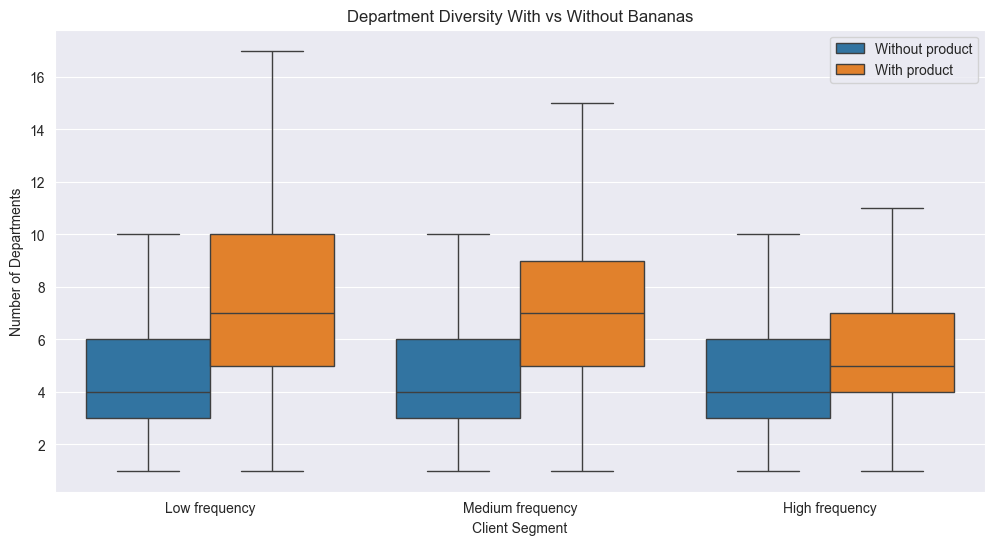

In [33]:
# Compute basket-level metrics for each order

basket_metrics = (
    df.groupby("order_id")
      .agg(
          basket_size=("product_id", "count"),
          dept_diversity=("department", "nunique"),
          user_id=("user_id", "first")
      )
      .reset_index()
)

# Compute overall order frequency for each customer
client_freq = (
    df.groupby("user_id")
      .agg(n_orders=("order_id", "nunique"))
      .reset_index()
)

# Segment customers into three groups (Low / Medium / High frequency) using quantiles to ensure balanced groups
client_freq["client_segment"] = pd.qcut(
    client_freq["n_orders"],
    q=3,
    labels=["Low frequency", "Medium frequency", "High frequency"]
)

basket_metrics = basket_metrics.merge(client_freq, on="user_id", how="left")

# Identify orders containing the target product for example banana
target_product = "Bananas"
orders_with_product = df.loc[
    df["product_name"] == target_product, "order_id"
].unique()

basket_metrics["product_present"] = basket_metrics["order_id"].isin(
    orders_with_product
)

basket_metrics["product_present"] = basket_metrics["product_present"].map(
    {True: "With product", False: "Without product"}
)

plt.figure(figsize=(12,6))
sns.boxplot(
    data=basket_metrics,
    x="client_segment",
    y="dept_diversity",
    hue="product_present",
    showfliers=False
)

plt.title(f"Department Diversity With vs Without {target_product}")
plt.xlabel("Client Segment")
plt.ylabel("Number of Departments")
plt.legend(title="")
plt.show()

### Reorder rate = average of reordered items

C:\Users\natha\AppData\Local\Temp\ipykernel_39100\4254602531.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



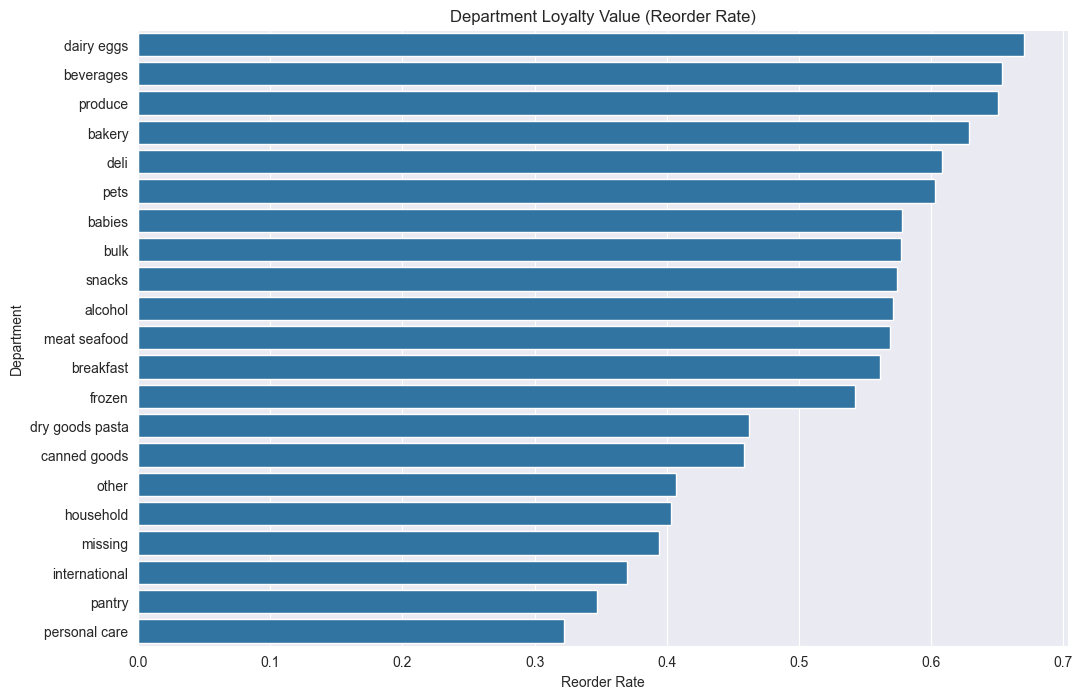

In [38]:
dept_reorder = (
    df
    .groupby('department')['reordered']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))
sns.barplot(x=dept_reorder.values, y=dept_reorder.index, order=dept_reorder.index)
plt.title("Department Loyalty Value (Reorder Rate)")
plt.xlabel("Reorder Rate")
plt.ylabel("Department")
plt.show()


###  Average number of items per order by department

C:\Users\natha\AppData\Local\Temp\ipykernel_39100\204183995.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



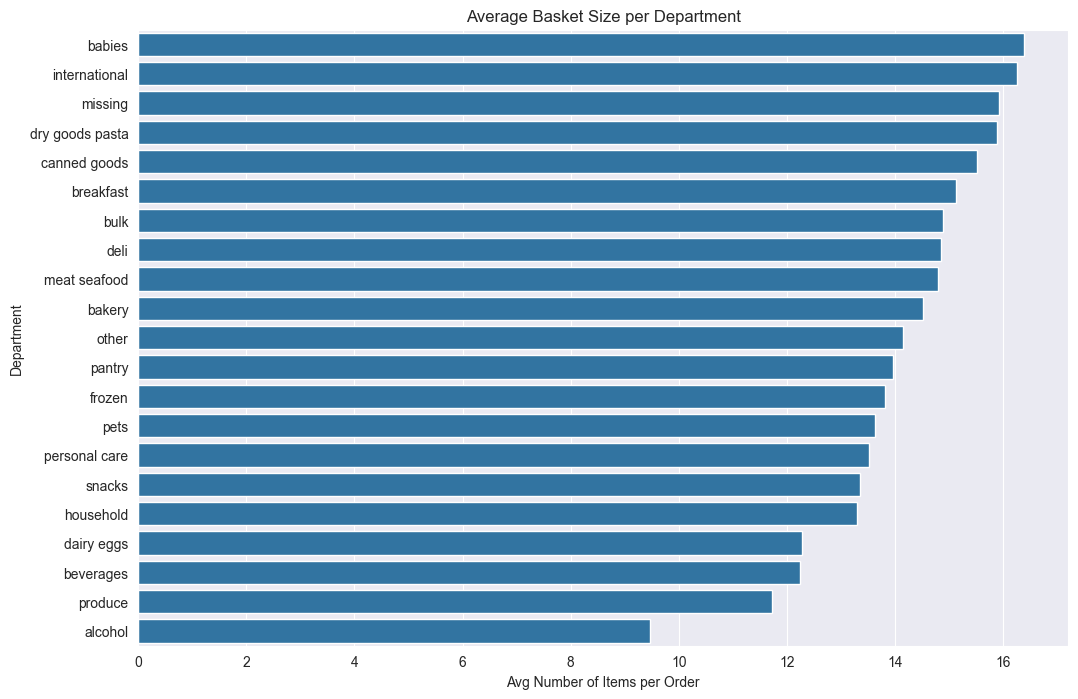

In [39]:
basket_size = df.groupby('order_id')['product_id'].count()

dept_basket = (
    df[['order_id', 'department']]
    .drop_duplicates()
    .merge(basket_size, on='order_id')
    .groupby('department')['product_id']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))
sns.barplot(x=dept_basket.values, y=dept_basket.index, order=dept_basket.index)
plt.title("Average Basket Size per Department")
plt.xlabel("Avg Number of Items per Order")
plt.ylabel("Department")
plt.show()

### Average basket size when the department is present vs global size

C:\Users\natha\AppData\Local\Temp\ipykernel_39100\1331531342.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



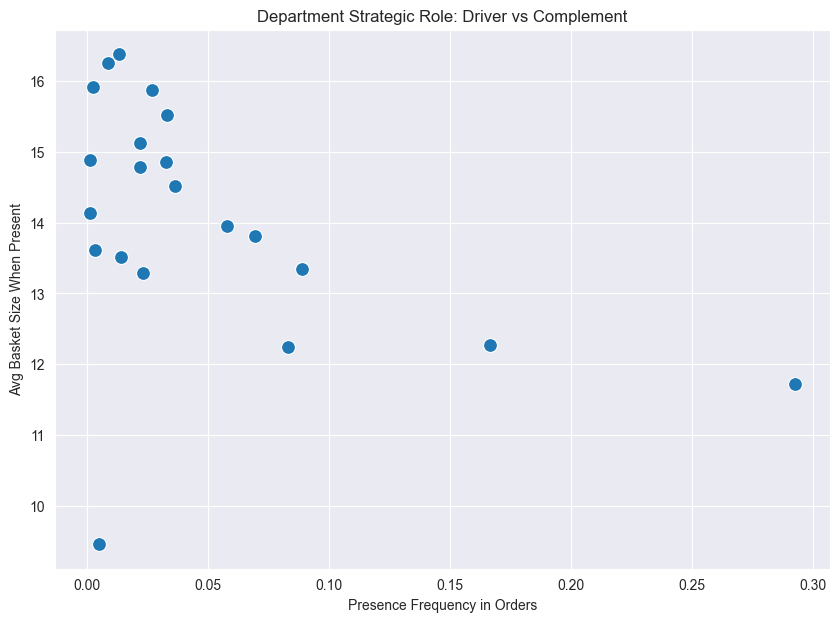

In [40]:
dept_orders = (
    df[['order_id', 'department']]
    .drop_duplicates()
)

basket_size_df = basket_size.reset_index(name='basket_size')

# Compute the average basket size for orders containing each department
# This tells us whether the department tends to appear in small or large baskets
dept_driver = (
    dept_orders
    .merge(basket_size_df, on='order_id')
    .groupby('department')['basket_size']
    .mean()
    .sort_values(ascending=False)
)

dept_freq = df['department'].value_counts(normalize=True)

# Combine department frequency and average basket size into a single dataframe
driver_df = pd.DataFrame({
    'freq': dept_freq,
    'basket_size': dept_driver
}).dropna()

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=driver_df,
    x='freq',
    y='basket_size',
    s=100
)

plt.title("Department Strategic Role: Driver vs Complement")
plt.xlabel("Presence Frequency in Orders")
plt.ylabel("Avg Basket Size When Present")
plt.show()

### Final value graph with all value dimensions aggregated

C:\Users\natha\AppData\Local\Temp\ipykernel_39100\3759762499.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\natha\AppData\Local\Temp\ipykernel_39100\3759762499.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\natha\AppData\Local\Temp\ipykernel_39100\3759762499.py:28: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\natha\AppData\Local\Temp\ipykernel_39100\3759762499.py:45: MatplotlibDepre

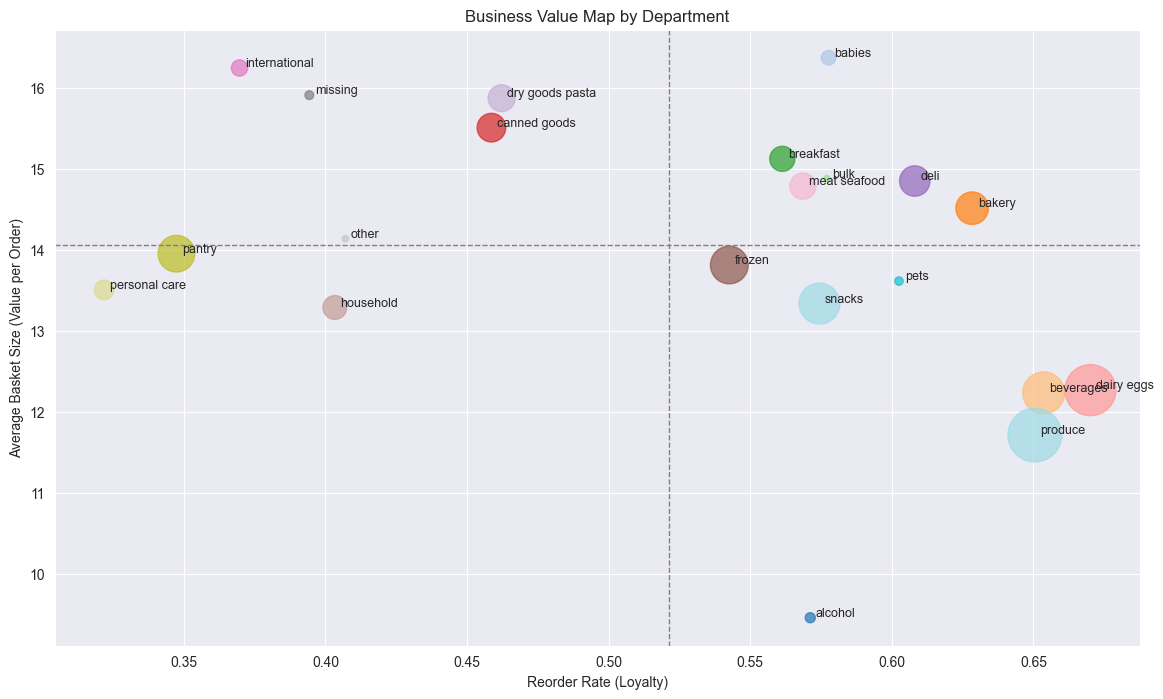

In [47]:
# 1. Reorder rate per department (customer loyalty)
reorder_rate = (
    df
    .groupby('department')['reordered']
    .mean()
)

# 2. Basket size per department (value per order)
basket_size = (
    df
    .groupby('order_id')['product_id']
    .count()
    .reset_index(name='basket_size')
)

dept_basket = (
    df[['order_id', 'department']]
    .drop_duplicates()
    .merge(basket_size, on='order_id')
    .groupby('department')['basket_size']
    .mean()
)

# 3. Presence frequency per department (engagement)
dept_freq = (
    df[['order_id', 'department']]
    .drop_duplicates()
    .groupby('department')
    .size()
)

# 4. Final value DataFrame
value_df = pd.DataFrame({
    'reorder_rate': reorder_rate,
    'avg_basket_size': dept_basket,
    'order_freq': dept_freq
}).dropna()

# Normalize bubble sizes for better visualization
value_df['bubble_size'] = (
    value_df['order_freq'] / value_df['order_freq'].max()
) * 1500

departments = value_df.index.tolist()
cmap = cm.get_cmap('tab20', len(departments))
colors = [cmap(i) for i in range(len(departments))]
color_map = dict(zip(departments, colors))
color_list = [color_map[dept] for dept in departments]

mean_x = value_df['reorder_rate'].mean()
mean_y = value_df['avg_basket_size'].mean()

plt.figure(figsize=(14,8))
plt.scatter(
    value_df['reorder_rate'],
    value_df['avg_basket_size'],
    s=value_df['bubble_size'],
    alpha=0.7,
    c=color_list
)

plt.axvline(mean_x, linestyle='--', color='gray', linewidth=1)
plt.axhline(mean_y, linestyle='--', color='gray', linewidth=1)

for dept in value_df.index:
    plt.text(
        value_df.loc[dept, 'reorder_rate'] + 0.002,
        value_df.loc[dept, 'avg_basket_size'] + 0.02,
        dept,
        fontsize=9
    )

plt.xlabel("Reorder Rate (Loyalty)")
plt.ylabel("Average Basket Size (Value per Order)")
plt.title("Business Value Map by Department")

plt.show()


This graph summarises the business value of departments according to their ability to build customer loyalty, increase basket size and structure purchase frequency. It identifies long-term value drivers independently of prices. This value map shows that business performance depends on a balance between departments that generate recurring revenue and departments that generate value per order. The growth drivers differ depending on the quadrant.

**TOP Right** - Value Champions
- High loyalty and high value per order and High frequency

**TOP Left** - Loyal Niches
- Big Basket Size but low frequency

**BOTTOM Right** - Popular Commodities
- High frequency but low basket size

**BOTTOM Left** - Low Value
- Low loyalty, low basket size, low frequency